# Conformal Uncertainty Quantification for Mammographic Malignancy Classification

This notebook trains a single-view
DenseNet-121 classifier on CBIS-DDSM (benign vs malignant) and wraps it with
**split conformal prediction**, producing prediction sets with a distribution-free
marginal coverage guarantee. Three nonconformity scores are compared: 

* **LAC: Least Ambiguous set-valued Classifier (aka Threshold)**,
* **APS: Adaptive Prediction Sets**, and
* **RAPS: Regularized Adaptive Prediction Sets**.

Everything runs on the Kaggle-hosted CBIS-DDSM JPEG dataset — no local storage,
no DICOM handling. Set the accelerator to **GPU T4*2** before running.

**Run order:** top to bottom. A full run is ~1-2 GPU-hours at the default settings.
Appendix A at the end is an optional environment check that trains nothing.

**For a quick smoke test**: set `SMOKE_TEST = True` in the config cell.

## 1. Setup

In [1]:
import os, glob, time, json, random, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import roc_auc_score
from PIL import Image
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

def set_seed(s=27):
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)
if DEVICE == "cpu":
    print("WARNING: No GPU detected. Turn on the GPU T4*2 accelerator in Session options.")

Device: cuda


## 2. Configuration

`SMOKE_TEST = True` runs on a tiny subset for a few minutes to check the pipeline
end-to-end before you spend GPU quota on the real thing.

`group_aware_resplit` controls the multi-trial protocol in Section 10 — see the
note there before changing it.

In [2]:
class CFG:
    SMOKE_TEST   = False          # setting False for the real run
    data_root    = "/kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset"
    img_size     = 224
    batch_size   = 32
    epochs       = 1 if SMOKE_TEST else 12
    lr           = 1e-4
    weight_decay = 1e-4
    test_frac    = 0.20          # of all patients, held out as the test pool
    val_frac     = 0.15
    cal_frac     = 0.20          # of the non-test pool, held out for conformal calibration
    alpha        = 0.05          # target miscoverage -> 95% coverage
    n_conformal_trials = 100     # resamples of cal/test for the coverage distribution
    group_aware_resplit = False  # resampling by patient rather than by row (Section 10)
    raps_lam     = 0.01
    raps_kreg    = 1
    out_dir      = "/kaggle/working"
    seed         = 27

set_seed(CFG.seed)
os.makedirs(CFG.out_dir, exist_ok=True)

## 3. Build the label table

CBIS-DDSM on Kaggle ships its own CSVs. The mass and calcification case files carry
a `pathology` column (`MALIGNANT`, `BENIGN`, `BENIGN_WITHOUT_CALLBACK`) and an
`image file path`. We map pathology to a binary label and resolve each stored path
to a real JPEG by matching its trailing UID directory against the folders under the
`jpeg/` root, taking the largest file in that folder (the full mammogram rather than
the cropped-ROI thumbnail that shares it).

**Patient-level grouping** is preserved via `patient_id` so the split never
leaks a patient across train/cal/test — this is what keeps the conformal guarantee honest.

In [3]:
def find_csvs(root):
    hits = {}
    for dirpath, _, files in os.walk(root):
        for f in files:
            fl = f.lower()
            if fl.endswith(".csv"):
                hits.setdefault(fl, os.path.join(dirpath, f))
    return hits

csvs = find_csvs(CFG.data_root)
print("CSV files found:")
for k, v in sorted(csvs.items()):
    print(f"  {k}  ->  {v}")

CSV files found:
  calc_case_description_test_set.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_test_set.csv
  calc_case_description_train_set.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/calc_case_description_train_set.csv
  dicom_info.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/dicom_info.csv
  mass_case_description_test_set.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_test_set.csv
  mass_case_description_train_set.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/mass_case_description_train_set.csv
  meta.csv  ->  /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/csv/meta.csv


In [4]:
def load_case_table(csvs):
    """Concatenating the four case-description CSVs into one table with columns:
    patient_id, pathology, label, img_relpath."""
    frames = []
    for key in ["mass_case_description_train_set.csv",
                "mass_case_description_test_set.csv",
                "calc_case_description_train_set.csv",
                "calc_case_description_test_set.csv"]:
        if key in csvs:
            df = pd.read_csv(csvs[key])
            df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
            frames.append(df)
    if not frames:
        raise FileNotFoundError("No case-description CSVs found; check data_root.")
    cases = pd.concat(frames, ignore_index=True)
    # binary label: malignant = 1, everything benign = 0
    cases["label"] = (cases["pathology"].str.upper() == "MALIGNANT").astype(int)
    # the column holding the full mammogram image path varies by CSV version
    path_col = None
    for cand in ["image_file_path", "image_file_path_", "cropped_image_file_path"]:
        if cand in cases.columns:
            path_col = cand; break
    if path_col is None:
        raise KeyError(f"No image path column in {list(cases.columns)}")
    cases["img_relpath"] = cases[path_col].astype(str)
    # patient id column
    pid_col = "patient_id" if "patient_id" in cases.columns else cases.columns[0]
    cases["patient_id"] = cases[pid_col].astype(str)
    return cases[["patient_id", "pathology", "label", "img_relpath"]]

In [5]:
def make_file_resolver(data_root):
    '''Return a function mapping a stored relpath to a real file path.
    Matches on the trailing UID directory name under the jpeg root.'''
    jpeg_root = None
    for dirpath, dirs, _ in os.walk(data_root):
        if os.path.basename(dirpath).lower() in ("jpeg", "jpg"):
            jpeg_root = dirpath; break
    index = {}
    search_root = jpeg_root or data_root
    for dirpath, _, files in os.walk(search_root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                index.setdefault(os.path.basename(dirpath), []).append(
                    os.path.join(dirpath, f))
    def resolve(relpath):
        # the stored path usually contains a UID directory that matches a folder name
        parts = [p for p in relpath.replace("\\", "/").split("/") if p]
        for p in reversed(parts):
            if p in index:
                # pick the largest file in that folder (the full image, not a thumbnail)
                return max(index[p], key=os.path.getsize)
        return None
    return resolve

## 4. Dataset and dataloaders

In [6]:
class MammoDataset(Dataset):
    def __init__(self, df, resolver, train=False):
        self.df = df.reset_index(drop=True)
        self.resolver = resolver
        mean = [0.485, 0.456, 0.406]; std = [0.229, 0.224, 0.225]
        if train:
            self.tf = transforms.Compose([
                transforms.Grayscale(num_output_channels=3),
                transforms.Resize((CFG.img_size, CFG.img_size)),
                transforms.RandomHorizontalFlip(),
                transforms.RandomRotation(10),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])
        else:
            self.tf = transforms.Compose([
                transforms.Grayscale(num_output_channels=3),
                transforms.Resize((CFG.img_size, CFG.img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean, std),
            ])

    def __len__(self):
        return len(self.df)

    def __getitem__(self, i):
        row = self.df.iloc[i]
        path = self.resolver(row["img_relpath"])
        if path is None or not os.path.exists(path):
            img = Image.new("L", (CFG.img_size, CFG.img_size))
        else:
            img = Image.open(path).convert("L")
        return self.tf(img), int(row["label"])

## 5. Patient-level splits

Non-test pool -> train + calibration + validation, then a separate test set.
No `patient_id` appears in more than one split.

In [7]:
def patient_level_split(df, seed=27):
    rng = np.random.default_rng(seed)
    patients = df["patient_id"].unique()
    rng.shuffle(patients)
    n = len(patients)
    n_test = int(CFG.test_frac * n)
    n_cal  = int(CFG.cal_frac * (n - n_test))
    n_val  = int(CFG.val_frac * (n - n_test - n_cal))
    test_p = set(patients[:n_test])
    cal_p  = set(patients[n_test:n_test + n_cal])
    val_p  = set(patients[n_test + n_cal:n_test + n_cal + n_val])
    train_p = set(patients[n_test + n_cal + n_val:])
    def subset(pset): return df[df["patient_id"].isin(pset)].copy()
    return subset(train_p), subset(val_p), subset(cal_p), subset(test_p)

## 6. Model — DenseNet-121

In [8]:
def build_model():
    m = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
    m.classifier = nn.Linear(m.classifier.in_features, 2)
    return m.to(DEVICE)

## 7. Training loop

In [9]:
def train_model(model, train_dl, val_dl):
    opt = torch.optim.AdamW(model.parameters(), lr=CFG.lr,
                            weight_decay=CFG.weight_decay)
    crit = nn.CrossEntropyLoss()
    best_val, best_state = 0.0, None
    for ep in range(CFG.epochs):
        model.train(); t0 = time.time()
        for x, y in train_dl:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(x), y)
            loss.backward(); opt.step()
        # validation accuracy
        model.eval(); correct = total = 0
        with torch.no_grad():
            for x, y in val_dl:
                x, y = x.to(DEVICE), y.to(DEVICE)
                pred = model(x).argmax(1)
                correct += (pred == y).sum().item(); total += len(y)
        acc = correct / max(total, 1)
        print(f"epoch {ep+1}/{CFG.epochs}  val_acc={acc:.3f}  ({time.time()-t0:.0f}s)")
        if acc >= best_val:
            best_val, best_state = acc, {k: v.cpu().clone()
                                         for k, v in model.state_dict().items()}
    if best_state:
        model.load_state_dict(best_state)
    return model, best_val

## 8. Extract softmax probabilities

In [10]:
@torch.no_grad()
def get_probs(model, dl):
    model.eval(); ps, ys = [], []
    for x, y in dl:
        x = x.to(DEVICE)
        p = torch.softmax(model(x), dim=1).cpu().numpy()
        ps.append(p); ys.append(y.numpy())
    return np.concatenate(ps), np.concatenate(ys)

## 9. Conformal prediction

The conformal routines are inlined here so the notebook is self-contained.
(Identical to the verified `conformal.py`.)

`conformal_quantile` is the single definition of the finite-sample corrected
quantile used everywhere below, and `_lac_cal` / `_lac_sets` are the single
definition of the LAC score — Sections 14-16 call these rather than
re-deriving them.

In [11]:
def conformal_quantile(cal_scores, alpha):
    n = len(cal_scores)
    level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    return np.quantile(cal_scores, level, method="higher")

# --- LAC -------------------------------------------------------------------
def _lac_cal(p, y): return 1.0 - p[np.arange(len(y)), y]
def _lac_sets(p, q): return p >= (1.0 - q)

# --- shared cumulative-rank machinery for APS / RAPS ------------------------
def _sorted_cumulative(p):
    '''Descending sort of p with its cumulative sums. Returns (order, sp, cum).'''
    order = np.argsort(-p, 1)
    sp = np.take_along_axis(p, order, 1)
    return order, sp, np.cumsum(sp, 1)

def _cal_mass_before_true(p, y):
    '''Probability mass ranked strictly above the true label, plus its rank.'''
    n = len(y)
    order, sp, cum = _sorted_cumulative(p)
    ranks = np.argmax(order == y[:, None], 1)
    before = cum[np.arange(n), ranks] - sp[np.arange(n), ranks]
    return before, ranks

def _sets_from_scores(score, order, q):
    inc = score <= q; inc[:, 0] = True
    out = np.zeros(order.shape, bool)
    np.put_along_axis(out, order, inc, 1)
    return out

# --- APS -------------------------------------------------------------------
def _aps_cal(p, y, rng):
    before, _ = _cal_mass_before_true(p, y)
    return before + rng.uniform(size=len(y)) * p[np.arange(len(y)), y]

def _aps_sets(p, q, rng):
    order, sp, cum = _sorted_cumulative(p)
    score = cum - rng.uniform(size=(p.shape[0], 1)) * sp
    return _sets_from_scores(score, order, q)

# --- RAPS = APS + rank regularisation --------------------------------------
def _raps_cal(p, y, rng, lam, kreg):
    before, ranks = _cal_mass_before_true(p, y)
    reg = lam * np.maximum(0, (ranks + 1) - kreg)
    return before + rng.uniform(size=len(y)) * p[np.arange(len(y)), y] + reg

def _raps_sets(p, q, rng, lam, kreg):
    order, sp, cum = _sorted_cumulative(p)
    K = p.shape[1]
    reg = lam * np.maximum(0, np.arange(1, K + 1)[None, :] - kreg)
    score = cum - rng.uniform(size=(p.shape[0], 1)) * sp + reg
    return _sets_from_scores(score, order, q)

def evaluate_sets(sets, y):
    n = len(y); covered = sets[np.arange(n), y]; sizes = sets.sum(1)
    return dict(coverage=float(covered.mean()),
                avg_set_size=float(sizes.mean()),
                frac_singleton=float((sizes == 1).mean()))

## 10. Multi-trial conformal evaluation

We pool the calibration and test probabilities — two patient-disjoint splits — then
repeatedly resample the cal/test boundary `n_conformal_trials` times to report the
**distribution** of coverage and set size, a far stronger claim than a single split.

The pooled set is patient-disjoint from training, so exchangeability holds and the
conformal guarantee is valid. Note what the resampling does and does not preserve:

* `group_aware_resplit = False` (default) permutes **rows**. Within a single trial the
  same patient's CC and MLO views can land on opposite sides of the cal/test boundary.
  The guarantee still holds under exchangeability, but the trial-to-trial spread is
  mildly optimistic because those two views are correlated.
* `group_aware_resplit = True` permutes **patients**, so no patient spans the boundary
  in any trial. This is the stricter protocol. It shifts the reported numbers slightly,
  so only switch it on if you are prepared to re-run and update the poster/paper.

In [12]:
def run_conformal_study(pool_probs, pool_labels, pool_pids=None):
    rng_master = np.random.default_rng(CFG.seed)
    methods = ["lac", "aps", "raps"]
    records = {m: {"coverage": [], "avg_set_size": [], "frac_singleton": []}
               for m in methods}
    n = len(pool_labels)
    group_aware = CFG.group_aware_resplit and pool_pids is not None
    if group_aware:
        uniq = np.unique(pool_pids)

    for t in range(CFG.n_conformal_trials):
        if group_aware:
            # split by patient, filling the calibration side until it holds ~half the rows
            order = rng_master.permutation(uniq)
            counts = pd.Series(pool_pids).value_counts()
            cum, cal_pats = 0, set()
            for p in order:
                if cum >= n // 2:
                    break
                cal_pats.add(p); cum += int(counts[p])
            is_cal = np.isin(pool_pids, list(cal_pats))
            cal_i, tst_i = np.where(is_cal)[0], np.where(~is_cal)[0]
        else:
            idx = rng_master.permutation(n)
            n_cal = n // 2
            cal_i, tst_i = idx[:n_cal], idx[n_cal:]

        cp, cy = pool_probs[cal_i], pool_labels[cal_i]
        tp, ty = pool_probs[tst_i], pool_labels[tst_i]
        rng = np.random.default_rng(t)
        for m in methods:
            if m == "lac":
                q = conformal_quantile(_lac_cal(cp, cy), CFG.alpha); s = _lac_sets(tp, q)
            elif m == "aps":
                q = conformal_quantile(_aps_cal(cp, cy, rng), CFG.alpha); s = _aps_sets(tp, q, rng)
            else:
                q = conformal_quantile(_raps_cal(cp, cy, rng, CFG.raps_lam, CFG.raps_kreg), CFG.alpha)
                s = _raps_sets(tp, q, rng, CFG.raps_lam, CFG.raps_kreg)
            e = evaluate_sets(s, ty)
            for k in records[m]:
                records[m][k].append(e[k])
    return records

## 11. Run everything

In [13]:
cases = load_case_table(csvs)
if CFG.SMOKE_TEST:
    cases = cases.groupby("label", group_keys=False).apply(
        lambda d: d.sample(min(len(d), 120), random_state=27))
print("Cases:", len(cases), "| malignant frac:", round(cases["label"].mean(), 3))

resolver = make_file_resolver(CFG.data_root)
train_df, val_df, cal_df, test_df = patient_level_split(cases, seed=CFG.seed)
print(f"train={len(train_df)}  val={len(val_df)}  cal={len(cal_df)}  test={len(test_df)}")

train_dl = DataLoader(MammoDataset(train_df, resolver, train=True),
                      batch_size=CFG.batch_size, shuffle=True, num_workers=2)
val_dl   = DataLoader(MammoDataset(val_df, resolver), batch_size=CFG.batch_size, num_workers=2)
cal_dl   = DataLoader(MammoDataset(cal_df, resolver), batch_size=CFG.batch_size, num_workers=2)
test_dl  = DataLoader(MammoDataset(test_df, resolver), batch_size=CFG.batch_size, num_workers=2)

Cases: 3568 | malignant frac: 0.408
train=1951  val=352  cal=595  test=670


In [14]:
model = build_model()
model, best_val = train_model(model, train_dl, val_dl)
print("Best val accuracy:", round(best_val, 3))

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 171MB/s]


epoch 1/12  val_acc=0.690  (281s)
epoch 2/12  val_acc=0.702  (272s)
epoch 3/12  val_acc=0.611  (273s)
epoch 4/12  val_acc=0.722  (269s)
epoch 5/12  val_acc=0.713  (267s)
epoch 6/12  val_acc=0.710  (270s)
epoch 7/12  val_acc=0.722  (272s)
epoch 8/12  val_acc=0.707  (273s)
epoch 9/12  val_acc=0.696  (271s)
epoch 10/12  val_acc=0.668  (267s)
epoch 11/12  val_acc=0.733  (274s)
epoch 12/12  val_acc=0.716  (273s)
Best val accuracy: 0.733


In [15]:
cal_probs, cal_labels = get_probs(model, cal_dl)
test_probs, test_labels = get_probs(model, test_dl)
pool_probs = np.concatenate([cal_probs, test_probs])
pool_labels = np.concatenate([cal_labels, test_labels])
# cal_dl / test_dl are unshuffled, so patient ids line up row-for-row with the pool
pool_pids = np.concatenate([cal_df["patient_id"].values, test_df["patient_id"].values])

# base classifier metrics
test_pred = test_probs.argmax(1)
base_acc = float((test_labels == test_pred).mean())
try:
    base_auc = roc_auc_score(test_labels, test_probs[:, 1])
except ValueError:
    base_auc = float("nan")
print(f"Base classifier: acc={base_acc:.3f}  auc={base_auc:.3f}")

Base classifier: acc=0.643  auc=0.708


In [16]:
records = run_conformal_study(pool_probs, pool_labels, pool_pids)

summary = {}
print(f"\n{'method':6s} {'coverage':>18s} {'set size':>16s} {'singleton':>12s}")
print("-" * 56)
for m in ["lac", "aps", "raps"]:
    cov = np.array(records[m]["coverage"])
    sz  = np.array(records[m]["avg_set_size"])
    sg  = np.array(records[m]["frac_singleton"])
    summary[m] = dict(cov_mean=float(cov.mean()), cov_sd=float(cov.std()),
                      size_mean=float(sz.mean()), size_sd=float(sz.std()),
                      singleton_mean=float(sg.mean()))
    print(f"{m.upper():6s} {cov.mean():.3f} +/- {cov.std():.3f}   "
          f"{sz.mean():.3f} +/- {sz.std():.3f}   {sg.mean():.3f}")


method           coverage         set size    singleton
--------------------------------------------------------
LAC    0.954 +/- 0.013   1.694 +/- 0.027   0.306
APS    0.953 +/- 0.012   1.720 +/- 0.028   0.280
RAPS   0.953 +/- 0.012   1.714 +/- 0.029   0.286


## 12. Figures for the poster

Saved figure -> /kaggle/working/conformal_results.png


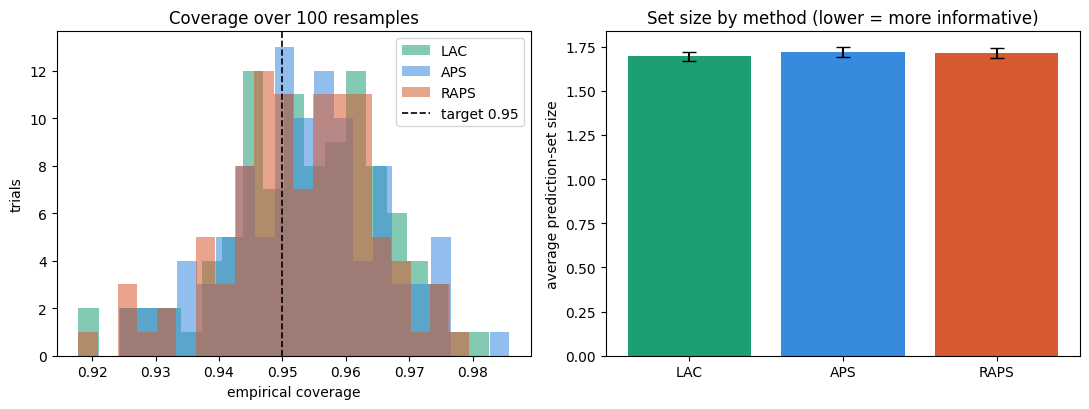

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"lac": "#1D9E75", "aps": "#378ADD", "raps": "#D85A30"}

for m in ["lac", "aps", "raps"]:
    axes[0].hist(records[m]["coverage"], bins=20, alpha=0.55,
                 label=m.upper(), color=colors[m])
axes[0].axvline(1 - CFG.alpha, color="black", ls="--", lw=1.2,
                label=f"target {1-CFG.alpha:.2f}")
axes[0].set_xlabel("empirical coverage"); axes[0].set_ylabel("trials")
axes[0].set_title(f"Coverage over {CFG.n_conformal_trials} resamples"); axes[0].legend()

means = [summary[m]["size_mean"] for m in ["lac", "aps", "raps"]]
sds   = [summary[m]["size_sd"] for m in ["lac", "aps", "raps"]]
axes[1].bar(["LAC", "APS", "RAPS"], means, yerr=sds, capsize=5,
            color=[colors[m] for m in ["lac", "aps", "raps"]])
axes[1].set_ylabel("average prediction-set size")
axes[1].set_title("Set size by method (lower = more informative)")
plt.tight_layout()
fig.savefig(f"{CFG.out_dir}/conformal_results.png", dpi=200, bbox_inches="tight")
print("Saved figure ->", f"{CFG.out_dir}/conformal_results.png")
plt.show()

## 13. Persist results for the writeup

In [18]:
results_blob = {
    "base_classifier": {"val_acc": best_val, "test_acc": float(base_acc),
                        "test_auc": float(base_auc)},
    "config": {k: getattr(CFG, k) for k in
               ["alpha", "epochs", "img_size", "n_conformal_trials",
                "raps_lam", "raps_kreg", "group_aware_resplit", "SMOKE_TEST"]},
    "conformal": summary,
    "counts": {"train": len(train_df), "val": len(val_df),
               "cal": len(cal_df), "test": len(test_df)},
}
with open(f"{CFG.out_dir}/results.json", "w") as f:
    json.dump(results_blob, f, indent=2)
print(json.dumps(results_blob, indent=2))
print("\nSaved -> /kaggle/working/results.json and conformal_results.png")

{
  "base_classifier": {
    "val_acc": 0.7329545454545454,
    "test_acc": 0.6432835820895523,
    "test_auc": 0.7084626775137373
  },
  "config": {
    "alpha": 0.05,
    "epochs": 12,
    "img_size": 224,
    "n_conformal_trials": 100,
    "raps_lam": 0.01,
    "raps_kreg": 1,
    "group_aware_resplit": false,
    "SMOKE_TEST": false
  },
  "conformal": {
    "lac": {
      "cov_mean": 0.9536492890995261,
      "cov_sd": 0.012531580017804555,
      "size_mean": 1.6940758293838862,
      "size_sd": 0.02651900053069862,
      "singleton_mean": 0.30592417061611377
    },
    "aps": {
      "cov_mean": 0.9534597156398106,
      "cov_sd": 0.012351446007196393,
      "size_mean": 1.7204581358609794,
      "size_sd": 0.028438103311356593,
      "singleton_mean": 0.2795418641390206
    },
    "raps": {
      "cov_mean": 0.9527962085308057,
      "cov_sd": 0.01195691172799952,
      "size_mean": 1.713522906793049,
      "size_sd": 0.02911873093738044,
      "singleton_mean": 0.28647709320695

## 14. Additional analysis — class-conditional coverage + Mondrian fix

Marginal conformal prediction guarantees coverage *on average*, but can still
under-cover one class. In screening, under-covering **malignant** is the
dangerous failure. We measure per-class coverage, then fix any gap with
**Mondrian (class-conditional) conformal prediction** — a separate threshold
calibrated per class. Reuses cal_probs / test_probs; no retraining.

Class-conditional coverage (target 0.95):
  Benign      marginal=0.929   mondrian=0.907
  Malignant   marginal=0.893   mondrian=0.960


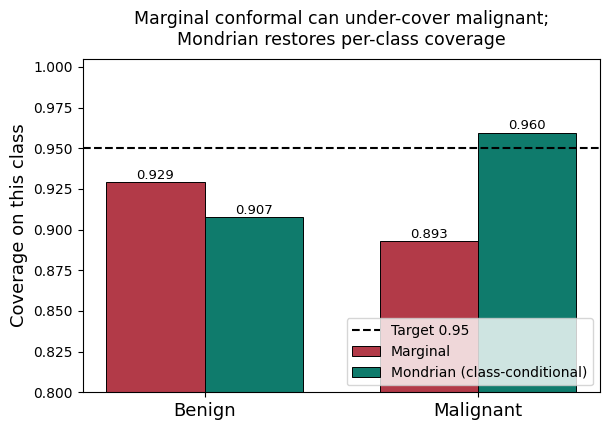

saved fig_classcond.png


In [19]:
CLASS_NAMES = ["Benign", "Malignant"]
K = test_probs.shape[1]

# marginal LAC threshold (one global qhat)
q_marg = conformal_quantile(_lac_cal(cal_probs, cal_labels), CFG.alpha)
sets_marg = _lac_sets(test_probs, q_marg)

# Mondrian LAC: one qhat per class, calibrated only on that class's examples
q_class = np.zeros(K)
for k in range(K):
    m = cal_labels == k
    q_class[k] = conformal_quantile(1.0 - cal_probs[m, k], CFG.alpha)
sets_mond = np.zeros_like(test_probs, dtype=bool)
for k in range(K):
    sets_mond[:, k] = test_probs[:, k] >= (1.0 - q_class[k])

def _classwise(sets):
    return [float(sets[test_labels == k, k].mean()) if (test_labels == k).any()
            else float("nan") for k in range(K)]

cov_marg = _classwise(sets_marg)
cov_mond = _classwise(sets_mond)
print(f"Class-conditional coverage (target {1-CFG.alpha:.2f}):")
for k in range(K):
    print(f"  {CLASS_NAMES[k]:10s}  marginal={cov_marg[k]:.3f}   mondrian={cov_mond[k]:.3f}")

fig, ax = plt.subplots(figsize=(6.2, 4.4))
x = np.arange(K); w = 0.36
b1 = ax.bar(x - w/2, cov_marg, w, label="Marginal", color="#B23A48", edgecolor="black", lw=0.7)
b2 = ax.bar(x + w/2, cov_mond, w, label="Mondrian (class-conditional)",
            color="#0F7B6C", edgecolor="black", lw=0.7)
ax.axhline(1 - CFG.alpha, ls="--", color="black", lw=1.5, label=f"Target {1-CFG.alpha:.2f}")
ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=13)
ax.set_ylabel("Coverage on this class", fontsize=13)
ax.set_ylim(min(0.80, min(cov_marg+cov_mond) - 0.03), 1.005)
ax.set_title("Marginal conformal can under-cover malignant;\nMondrian restores per-class coverage",
             fontsize=12.5, pad=10)
ax.legend(fontsize=10, loc="lower right")
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.002,
                f"{b.get_height():.3f}", ha="center", fontsize=9.5)
plt.tight_layout()
fig.savefig(f"{CFG.out_dir}/fig_classcond.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("saved fig_classcond.png")

## 15. Additional analysis — clinical decision curve (singleton rate vs alpha)

Raising alpha loosens the guarantee but resolves more cases to a single label
(more automation). This is the operating-point curve a clinical team would use
to trade coverage against workload.

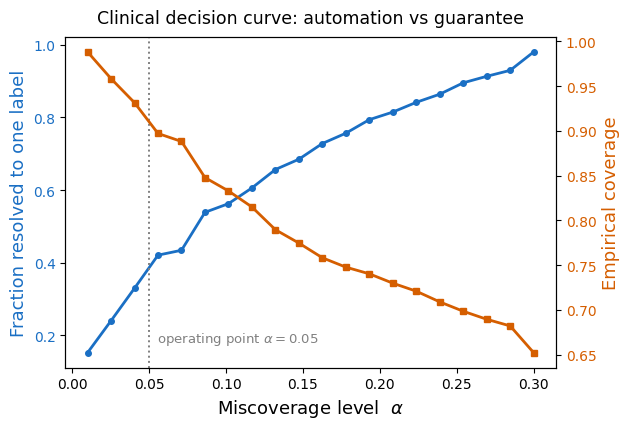

saved fig_decision_curve.png


In [20]:
alphas = np.linspace(0.01, 0.30, 20)
cov_list, singo_list, size_list = [], [], []
cal_scores = _lac_cal(cal_probs, cal_labels)
for a in alphas:
    q = conformal_quantile(cal_scores, a)
    s = _lac_sets(test_probs, q)
    sizes = s.sum(1)
    cov_list.append(float(s[np.arange(len(test_labels)), test_labels].mean()))
    singo_list.append(float((sizes == 1).mean()))
    size_list.append(float(sizes.mean()))

fig, ax1 = plt.subplots(figsize=(6.4, 4.4))
ax1.plot(alphas, singo_list, "-o", color="#1A6FC4", lw=2, ms=4)
ax1.set_xlabel(r"Miscoverage level  $\alpha$", fontsize=13)
ax1.set_ylabel("Fraction resolved to one label", color="#1A6FC4", fontsize=13)
ax1.tick_params(axis="y", labelcolor="#1A6FC4")
ax1.axvline(CFG.alpha, ls=":", color="grey", lw=1.4)
ax1.text(CFG.alpha + 0.005, min(singo_list)+0.03,
         rf"operating point $\alpha={CFG.alpha}$", fontsize=9.5, color="grey")
ax2 = ax1.twinx()
ax2.plot(alphas, cov_list, "-s", color="#D55E00", lw=2, ms=4)
ax2.set_ylabel("Empirical coverage", color="#D55E00", fontsize=13)
ax2.tick_params(axis="y", labelcolor="#D55E00")
ax1.set_title("Clinical decision curve: automation vs guarantee", fontsize=12.5, pad=10)
plt.tight_layout()
fig.savefig(f"{CFG.out_dir}/fig_decision_curve.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print("saved fig_decision_curve.png")

## 16. Additional analysis — real mammograms with their prediction sets

Three actual test images: a confident benign, a confident malignant, and an
ambiguous two-label case, each captioned with the model's probabilities and
the resulting LAC set (marginal threshold q_marg). Needs the real images, so
this only runs on Kaggle.

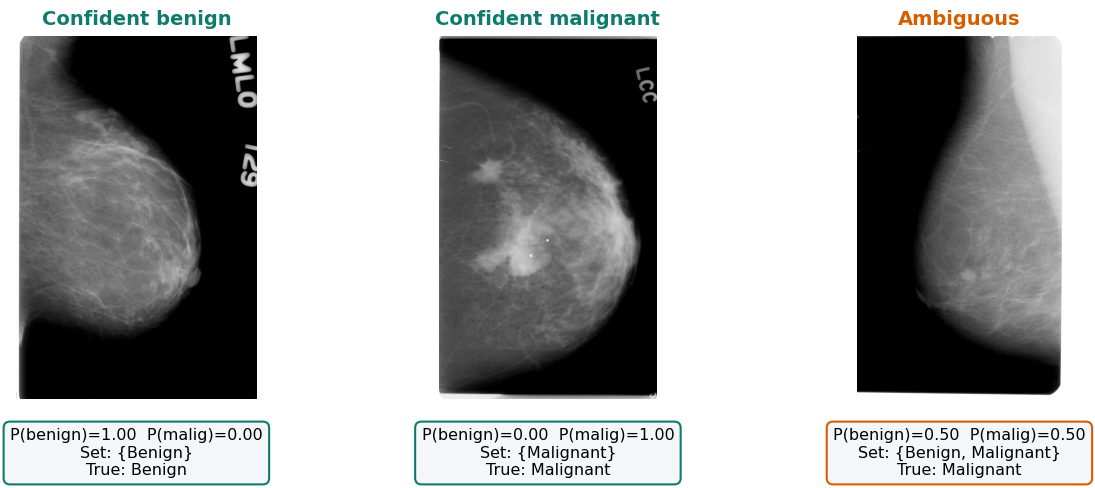

saved fig_examples.png  picked: {'Confident benign': 69, 'Confident malignant': 93, 'Ambiguous': 157}


In [21]:
test_rows = test_df.reset_index(drop=True)
p_mal = test_probs[:, 1]
sizes_m = sets_marg.sum(1)

conf_benign = np.where((sizes_m == 1) & (test_probs.argmax(1) == 0))[0]
conf_malig  = np.where((sizes_m == 1) & (test_probs.argmax(1) == 1))[0]
ambiguous   = np.where(sizes_m == 2)[0]

pick = {}
if len(conf_benign): pick["Confident benign"]    = int(conf_benign[np.argmin(p_mal[conf_benign])])
if len(conf_malig):  pick["Confident malignant"] = int(conf_malig[np.argmax(p_mal[conf_malig])])
if len(ambiguous):   pick["Ambiguous"]           = int(ambiguous[np.argmin(np.abs(p_mal[ambiguous]-0.5))])

if pick:
    fig, axes = plt.subplots(1, len(pick), figsize=(4.3*len(pick), 5.0))
    if len(pick) == 1: axes = [axes]
    for ax, (title, idx) in zip(axes, pick.items()):
        row = test_rows.iloc[idx]
        path = resolver(row["img_relpath"])
        if path and os.path.exists(path):
            ax.imshow(Image.open(path).convert("L"), cmap="gray")
        ax.axis("off")
        pr = test_probs[idx]
        inc = sets_marg[idx]
        setstr = ", ".join(CLASS_NAMES[k] for k in range(K) if inc[k])
        truth = CLASS_NAMES[int(test_labels[idx])]
        color = "#0F7B6C" if inc.sum() == 1 else "#D55E00"
        ax.set_title(title, fontsize=14, fontweight="bold", color=color, pad=8)
        ax.text(0.5, -0.08,
                f"P(benign)={pr[0]:.2f}  P(malig)={pr[1]:.2f}\nSet: {{{setstr}}}\nTrue: {truth}",
                transform=ax.transAxes, ha="center", va="top", fontsize=11.5,
                bbox=dict(boxstyle="round,pad=0.4", fc="#F4F6F9", ec=color, lw=1.5))
    plt.tight_layout()
    fig.savefig(f"{CFG.out_dir}/fig_examples.png", dpi=200, bbox_inches="tight", facecolor="white")
    plt.show()
    print("saved fig_examples.png  picked:", pick)
else:
    print("No example cases found — check that test_probs / sizes are populated.")

## 17. Additional analysis — reliability diagram (raw-classifier calibration)

Shows how far the raw softmax confidences are from observed accuracy — the
miscalibration that motivates conformal prediction. ECE summarizes the gap.

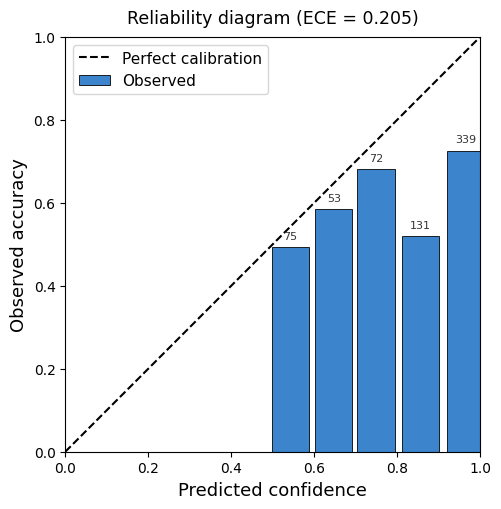

saved fig_reliability.png  ECE=0.205


In [22]:
def reliability(probs, labels, n_bins=10):
    conf = probs.max(1); pred = probs.argmax(1)
    correct = (pred == labels).astype(float)
    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, ns = [], [], []
    for i in range(n_bins):
        hi = conf <= edges[i+1] if i == n_bins-1 else conf < edges[i+1]
        m = (conf >= edges[i]) & hi
        if m.sum():
            xs.append(float(conf[m].mean())); ys.append(float(correct[m].mean())); ns.append(int(m.sum()))
    ece = sum(n*abs(x-y) for x, y, n in zip(xs, ys, ns)) / max(sum(ns), 1)
    return np.array(xs), np.array(ys), np.array(ns), float(ece)

bx, by, bn, ece = reliability(test_probs, test_labels, 10)
fig, ax = plt.subplots(figsize=(5.6, 5.2))
ax.plot([0, 1], [0, 1], "--", color="black", lw=1.5, label="Perfect calibration")
ax.bar(bx, by, width=0.09, color="#1A6FC4", edgecolor="black", lw=0.7, alpha=0.85, label="Observed")
for x, y, n in zip(bx, by, bn):
    ax.text(x, y+0.02, str(n), ha="center", fontsize=8, color="#333")
ax.set_xlabel("Predicted confidence", fontsize=13)
ax.set_ylabel("Observed accuracy", fontsize=13)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_title(f"Reliability diagram (ECE = {ece:.3f})", fontsize=12.5, pad=10)
ax.legend(fontsize=11, loc="upper left")
plt.tight_layout()
fig.savefig(f"{CFG.out_dir}/fig_reliability.png", dpi=200, bbox_inches="tight", facecolor="white")
plt.show()
print(f"saved fig_reliability.png  ECE={ece:.3f}")

## 18. Fold extended results into results.json

In [23]:
results_blob["extended"] = {
    "class_conditional": {
        "marginal": {CLASS_NAMES[k]: cov_marg[k] for k in range(K)},
        "mondrian": {CLASS_NAMES[k]: cov_mond[k] for k in range(K)},
        "mondrian_qhat": {CLASS_NAMES[k]: float(q_class[k]) for k in range(K)},
    },
    "decision_curve": {"alpha": list(map(float, alphas)),
                       "coverage": cov_list, "singleton": singo_list, "avg_size": size_list},
    "reliability": {"ece": ece, "bin_conf": list(map(float, bx)),
                    "bin_acc": list(map(float, by)), "bin_n": list(map(int, bn))},
}
with open(f"{CFG.out_dir}/results.json", "w") as f:
    json.dump(results_blob, f, indent=2)
print("results.json updated with extended analyses.")
print(json.dumps(results_blob["extended"]["class_conditional"], indent=2))

results.json updated with extended analyses.
{
  "marginal": {
    "Benign": 0.9290123456790124,
    "Malignant": 0.8930635838150289
  },
  "mondrian": {
    "Benign": 0.9074074074074074,
    "Malignant": 0.9595375722543352
  },
  "mondrian_qhat": {
    "Benign": 0.9105818271636963,
    "Malignant": 0.9763324856758118
  }
}


---

## Appendix A — Environment check 

Trains nothing. Confirms that `CFG.data_root` is correct, that the case CSVs are
present, and that the resolver returns full mammograms rather than the cropped-ROI
thumbnails sharing the same folders. Run it first if the pipeline errors on paths.

In [24]:
print("CFG.data_root:", CFG.data_root)
assert os.path.isdir(CFG.data_root), "data_root does not exist — check the dataset is attached."

jpeg_hits = glob.glob(os.path.join(CFG.data_root, "**", "jpeg"), recursive=True)
assert jpeg_hits, "No 'jpeg' folder under data_root."
jpeg_root = jpeg_hits[0]
print("jpeg root:", jpeg_root)
print("case CSVs found:", len(glob.glob(os.path.join(CFG.data_root, "**", "*.csv"), recursive=True)))

# sample folders and inspect what the largest-file rule resolves to
folders = [os.path.join(jpeg_root, d) for d in os.listdir(jpeg_root)][:200]
sizes, n_multi = [], 0
for fld in folders:
    if not os.path.isdir(fld):
        continue
    imgs = [os.path.join(fld, f) for f in os.listdir(fld)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))]
    if not imgs:
        continue
    n_multi += len(imgs) > 1
    try:
        with Image.open(max(imgs, key=os.path.getsize)) as im:
            sizes.append(im.size)
    except Exception as e:
        print("  FAILED to open a file in", fld, "->", e)

print(f"\nSampled {len(sizes)} folders; {n_multi} contained more than one image.")
if sizes:
    ws = np.array([s[0] for s in sizes]); hs = np.array([s[1] for s in sizes])
    print(f"Resolved dimensions: width {ws.min()}-{ws.max()} (median {int(np.median(ws))}), "
          f"height {hs.min()}-{hs.max()} (median {int(np.median(hs))})")
    small = int(((ws < 300) & (hs < 300)).sum())
    print(f"Folders whose largest file is still tiny (<300px both dims): {small}")
    print("  -> 0 means largest-file-per-folder correctly resolves to full mammograms.")

CFG.data_root: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset
jpeg root: /kaggle/input/datasets/awsaf49/cbis-ddsm-breast-cancer-image-dataset/jpeg
case CSVs found: 6

Sampled 200 folders; 103 contained more than one image.
Resolved dimensions: width 438-4816 (median 2992), height 448-6871 (median 5176)
Folders whose largest file is still tiny (<300px both dims): 0
  -> 0 means largest-file-per-folder correctly resolves to full mammograms.


In [25]:
from IPython.display import FileLink, display
for f in ["results.json", "conformal_results.png", "fig_classcond.png",
          "fig_decision_curve.png", "fig_examples.png", "fig_reliability.png"]:
    display(FileLink(f"/kaggle/working/{f}"))

/kaggle/working/results.json

/kaggle/working/conformal_results.png

/kaggle/working/fig_classcond.png

/kaggle/working/fig_decision_curve.png

/kaggle/working/fig_examples.png

/kaggle/working/fig_reliability.png